In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)
from utils import *

In [2]:
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model = YOLO(os.path.join(model_path, "yolov8n.pt"))
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name =  'real_test'

In [4]:
#!pip install colormath


0: 352x640 16 persons, 7.1ms
Speed: 1.5ms preprocess, 7.1ms inference, 0.9ms postprocess per image at shape (1, 3, 352, 640)
/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)

0: 288x640 9 persons, 8.8ms
Speed: 1.2ms preprocess, 8.8ms inference, 0.8ms postprocess per image at shape (1, 3, 288, 640)
/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)

0: 384x640 4 persons, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
/home/huy-ng/P

[2, 2, 1]


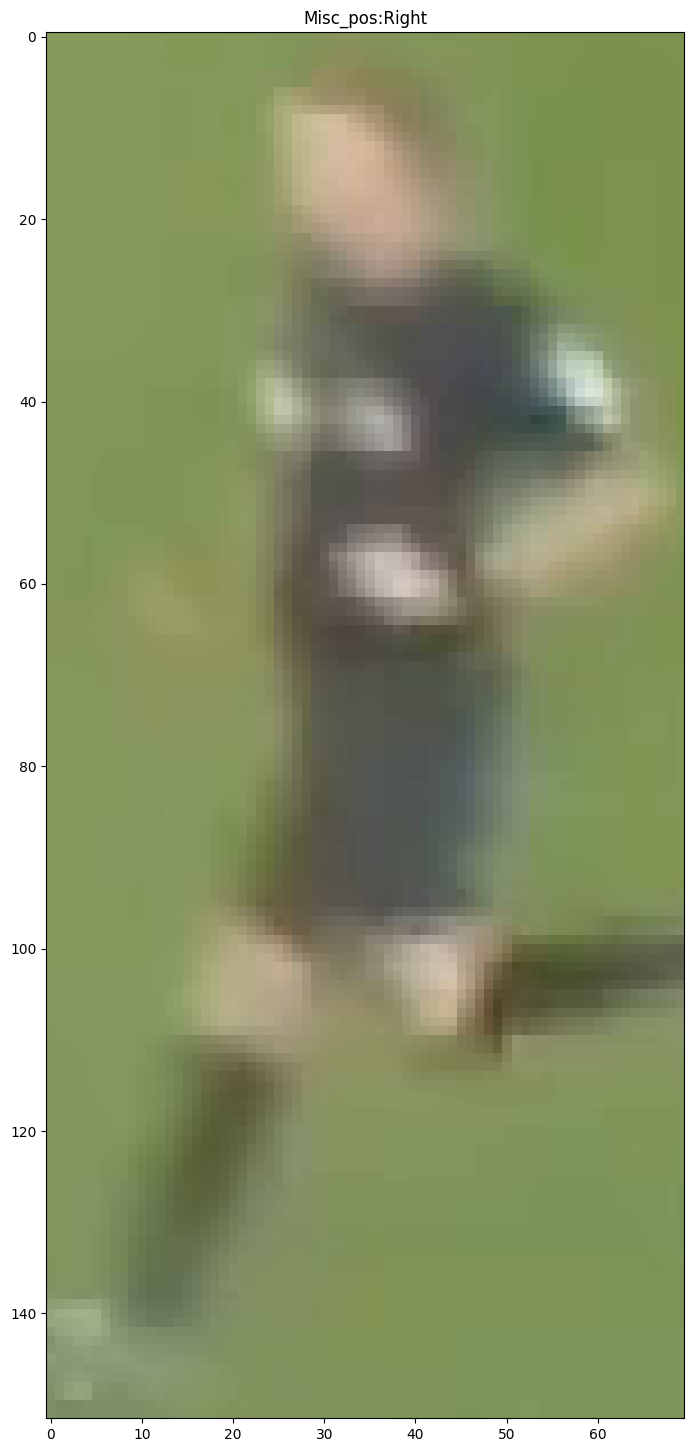

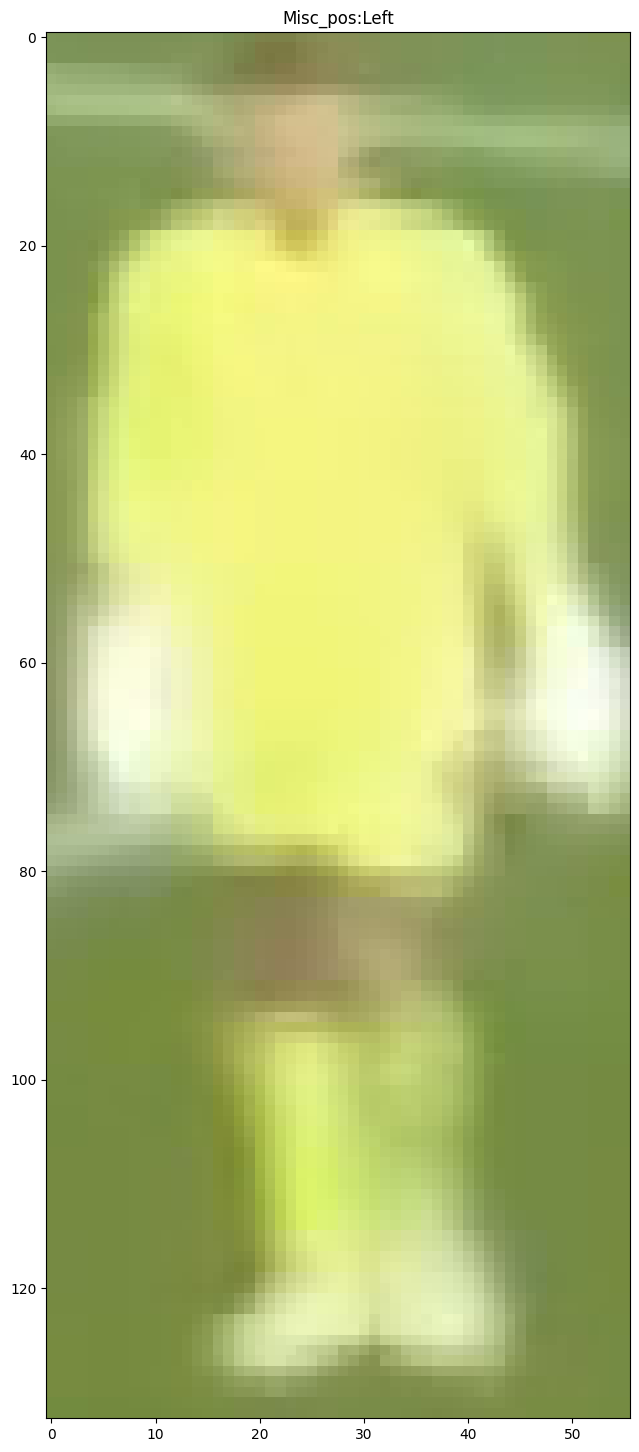

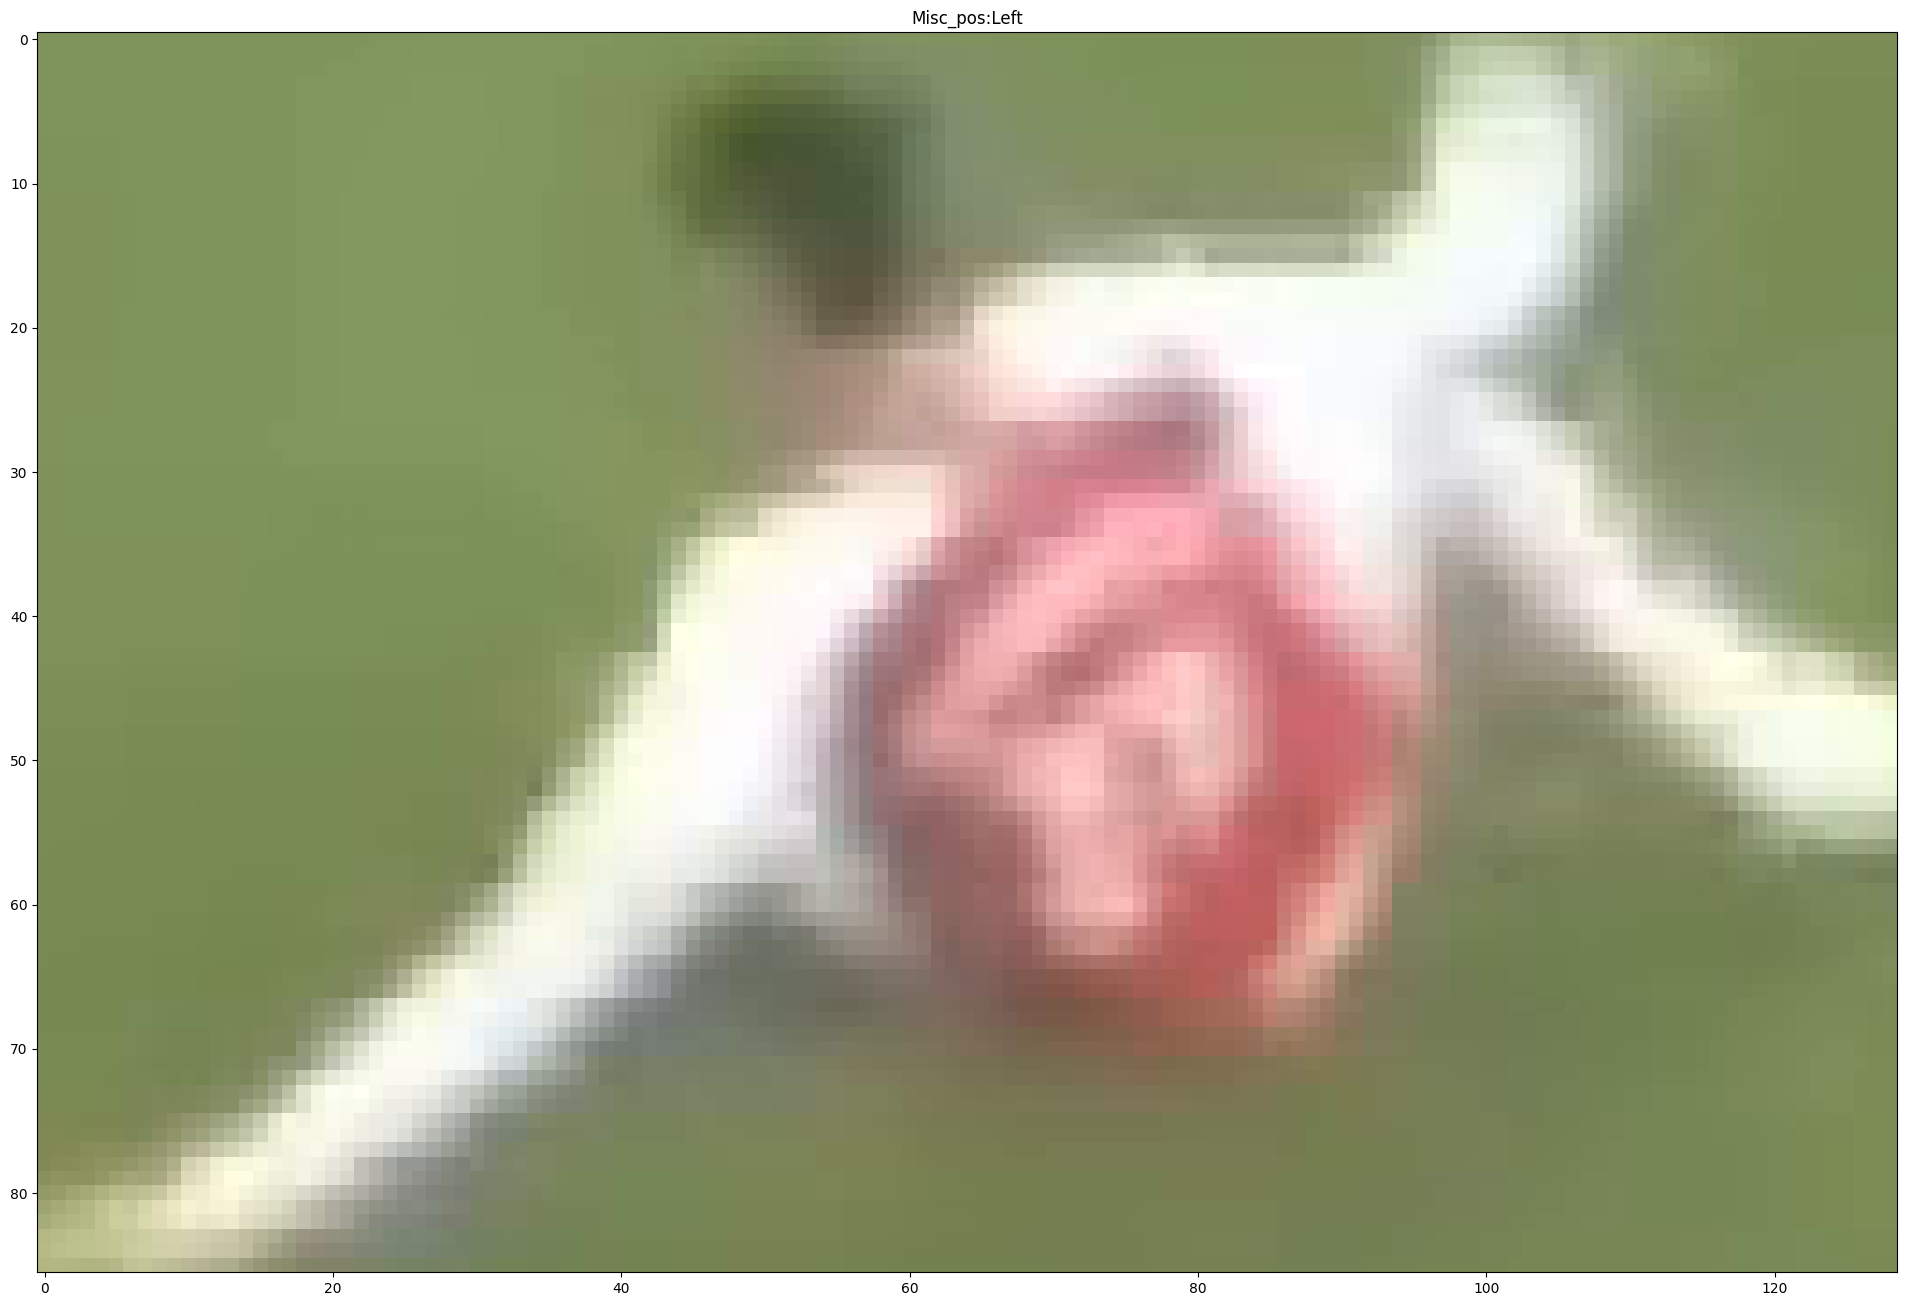

In [9]:
# Get several images to test
images_path = os.path.join(data_path, 'images' + '/' + vid_name)  #print(os.path.exists(images_path))
first_batch = os.listdir(images_path)[50:55]
image_batch = [os.path.join(images_path, x) for x in first_batch]

# Attributes to identify colors
team_1_color_global = []
team_2_color_global = []

misc_color_global   = []
misc_position_global = []
misc_frequency_global = []
misc_img_global = []


frame_num = 0


for image_ad in image_batch:
    
    # Crop out the audiences via pitch segmentation
    rgb_image = cv2.imread(image_ad, cv2.COLOR_BGR2RGB)
    rgb_image = pitch_segmentation(rgb_image)

    # Run yolov8n on the current image and extract features from resulting boxes
    results = model.predict(rgb_image)
    boxes = results[0].boxes
    assignment,player_x_coord,crop_img_list = box_to_features(rgb_image, boxes)

    # Applies KNN with 3 clusters to find the most prominent colors as in rgb_color
    kmeans = KMeans(n_clusters=3)
    s=kmeans.fit(assignment)
    labels=kmeans.labels_
    # Extract the labels into 2 teams and misc color
    teams = Counter(labels).most_common(3)
    team_1_label = teams[0][0]
    team_2_label = teams[1][0]
    misc_label   = teams[2][0]

    #Return correct labels of (numbers) and the 2 team lab colors
    labels, lab_team_1_color, lab_team_2_color  = misc_in_teams(labels,assignment,teams)

    # Labeling via strings and consistency checks so that team X is always color Y:
    if frame_num == 0:
        team_1_color_global = lab_team_1_color 
        team_2_color_global = lab_team_2_color

        labels = list(map(lambda x: x if x != team_1_label else 'Team 1', labels))
        labels = list(map(lambda x: x if x != team_2_label else 'Team 2', labels))
        labels = list(map(lambda x: x if x != misc_label else 'Misc', labels))
        
    if frame_num > 0:
        global_1_vs_local_1 = delta_e_cie2000(team_1_color_global, lab_team_1_color)
        global_1_vs_local_2 = delta_e_cie2000(team_1_color_global, lab_team_2_color)
        if  global_1_vs_local_1 < global_1_vs_local_2:
            labels = list(map(lambda x: x if x != team_1_label else 'Team 1', labels))
            labels = list(map(lambda x: x if x != team_2_label else 'Team 2', labels))
        else: 
            labels = list(map(lambda x: x if x != team_2_label else 'Team 1', labels))
            labels = list(map(lambda x: x if x != team_1_label else 'Team 2', labels))
        labels = list(map(lambda x: x if x != misc_label else 'Misc', labels)) 

    # Updated teams indices
    new_team_1 = np.where(np.array(labels) == "Team 1")[0]
    new_team_2 = np.where(np.array(labels) == "Team 2")[0]
    new_misc   = np.where(np.array(labels) == "Misc")[0]    
    
    # Update the misc color: 
    current_misc_img   = [crop_img_list[i] for i in new_misc]
    current_misc_color = [assignment[i] for i in new_misc]
    current_misc_lab   = [rgb_to_lab(x) for x in current_misc_color]
    global_misc_lab    = [rgb_to_lab(x) for x in misc_color_global]
    team_1_diff = [delta_e_cie2000(team_1_color_global,x) for x in current_misc_lab]
    team_2_diff = [delta_e_cie2000(team_2_color_global,x) for x in current_misc_lab]
    current_misc_pos   = position_text(player_x_coord,new_team_1,new_team_2,new_misc)
    switch = [False]*len(current_misc_lab)

    # Check availability of the misc clr:
    if len(misc_color_global) == 0:
        for j in range(len(current_misc_color)):
            # If the same shade of color then update the param of existing global, but if it is not then addd into the list
            if (team_1_diff[j] < 30) or (team_2_diff[j] < 30):
                switch[j] = True
            if switch[j] == False:
                misc_img_global.append(current_misc_img[j])
                misc_color_global.append(current_misc_color[j])
                misc_position_global.append(current_misc_pos[j])
                misc_frequency_global.append(1)
    else:
        #global vs local:
        for j in range(len(current_misc_lab)):
            # If the same shade of color then update the param of existing global, but if it is not then add into the list
            if (team_1_diff[j] < 30) or (team_2_diff[j] < 30):
                switch[j] = True
            for i in range(len(global_misc_lab)):
                misc_diff = delta_e_cie2000(global_misc_lab[i], current_misc_lab[j])
                if misc_diff < 40:
                    if current_misc_pos[j] == misc_position_global[i]:
                        misc_frequency_global[i] += 1
                    else:
                        misc_frequency_global[i] += 1
                        misc_position_global[i] = "Mid"
                    switch[j] = True

        for j in range(len(current_misc_lab)):
            if switch[j] == False:
                if len(misc_color_global) <= 4:
                    misc_img_global.append(current_misc_img[j])
                    misc_color_global.append(current_misc_color[j])
                    misc_position_global.append(current_misc_pos[j])
                    misc_frequency_global.append(1)
                else:
                    if min(misc_frequency_global) == 1:
                        k = misc_frequency_global.index(min(misc_frequency_global))
                        misc_img_global[k] = current_misc_img[j]
                        misc_color_global[k] = current_misc_color[j]
                        misc_position_global[k] = current_misc_pos[j]
                        misc_frequency_global[k] = 1
    
    frame_num +=1

for r in range(len(misc_img_global)):
    plt.figure()
    plt.title("Misc_pos:" + misc_position_global[r])
    plt.imshow(misc_img_global[r])
print(misc_frequency_global)